<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Minimal_Hypercharge_Electric_Charge_Bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Minimal Hypercharge / Electric-Charge Bridge

This notebook tests the next algebraic step after the minimal closure-active \(SU(2)_L\) test:

\[
(Q_0,Q_{\rm ch})_L
\rightarrow
SU(2)_L
\rightarrow
SU(2)_L\times U(1)_Y
\rightarrow
U(1)_{\rm EM}.
\]

The previous notebook established that the left-active ECSM neutral--charged pair

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L
\]

admits the minimal \(SU(2)\) generator algebra, with

\[
T_3(Q_0)=+\frac12,
\qquad
T_3(Q_{\rm ch})=-\frac12.
\]

This notebook asks whether adding a minimal \(U(1)\)-like branch-phase / hypercharge label \(Y\) can reproduce a neutral/charged lepton-like split:

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2}.
\]

For a left-active lepton-like doublet, the minimal choice is:

\[
Y_L=-1.
\]

Then:

\[
Q(Q_0)=+\frac12-\frac12=0,
\qquad
Q(Q_{\rm ch})=-\frac12-\frac12=-1.
\]

This notebook also checks right-handed singlet-like assignments:

\[
Q_{{\rm ch},R}: \quad T_i=0,\quad Y_R=-2,\quad Q=-1,
\]

\[
Q_{0,R}: \quad T_i=0,\quad Y_R=0,\quad Q=0.
\]

This is not a derivation of the full electroweak theory. It is a minimal algebraic consistency test for the ECSM hypercharge/electric-charge bridge.

In [1]:
# CELL 1 — Imports and output directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_hypercharge_electric_charge_bridge_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_hypercharge_electric_charge_bridge_out


In [2]:
# CELL 2 — Define closure-active basis and SU(2)L generator T3

I2 = np.eye(2, dtype=complex)

T3 = 0.5 * np.array([[1, 0],
                     [0, -1]], dtype=complex)

Q0 = np.array([[1],
               [0]], dtype=complex)

Qch = np.array([[0],
                [1]], dtype=complex)

basis = {
    "Q0_neutral_closure_L": Q0,
    "Qch_charged_branch_L": Qch
}

print("T3 =")
print(T3)

print("\nBasis:")
for name, v in basis.items():
    print(name, "=", v.ravel())

T3 =
[[ 0.5+0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j]]

Basis:
Q0_neutral_closure_L = [1.+0.j 0.+0.j]
Qch_charged_branch_L = [0.+0.j 1.+0.j]


In [3]:
# CELL 3 — Define electric-charge operator Q = T3 + Y/2

def charge_operator_doublet(Y):
    return T3 + 0.5 * Y * I2

def eig_charge(state, Op, tol=1e-12):
    result = Op @ state
    idx = np.argmax(np.abs(state.ravel()))
    ev = result.ravel()[idx] / state.ravel()[idx]
    if abs(ev.imag) < tol:
        return float(ev.real)
    return ev

Y_L = -1
Qop_L = charge_operator_doublet(Y_L)

print("Y_L =", Y_L)
print("Q operator for left doublet =")
print(Qop_L)

rows = []
for name, state in basis.items():
    rows.append({
        "state": name,
        "T3": eig_charge(state, T3),
        "Y": Y_L,
        "Y/2": Y_L/2,
        "Q_ECSM = T3 + Y/2": eig_charge(state, Qop_L)
    })

left_charge_df = pd.DataFrame(rows)
display(left_charge_df)

left_charge_df.to_csv(OUT / "left_doublet_charge_assignments.csv", index=False)
print("Saved:", OUT / "left_doublet_charge_assignments.csv")

Y_L = -1
Q operator for left doublet =
[[ 0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


,state,T3,Y,Y/2,Q_ECSM = T3 + Y/2
0,Q0_neutral_closure_L,0.5,-1,-0.5,0.0
1,Qch_charged_branch_L,-0.5,-1,-0.5,-1.0


Saved: ecsm_hypercharge_electric_charge_bridge_out/left_doublet_charge_assignments.csv


## Interpretation of the left doublet result

For the closure-active ECSM pair,

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L,
\]

the assignment

\[
Y_L=-1
\]

gives

\[
Q_{\rm ECSM}(Q_0)=0,
\qquad
Q_{\rm ECSM}(Q_{\rm ch})=-1.
\]

Thus the same left-active doublet carries both a neutral branch and a charged branch, with charge arising from the unbroken combination

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2}.
\]

In [4]:
# CELL 4 — Scan hypercharge Y values and find values giving (0, -1)

Y_values = np.linspace(-3, 1, 401)
target = np.array([0.0, -1.0])

scan_rows = []
for Y in Y_values:
    Qop = charge_operator_doublet(Y)
    charges = np.array([eig_charge(Q0, Qop), eig_charge(Qch, Qop)], dtype=float)
    err = float(np.linalg.norm(charges - target))
    scan_rows.append({"Y": Y, "Q_Q0": charges[0], "Q_Qch": charges[1], "target_error": err})

scan_df = pd.DataFrame(scan_rows)
best_idx = int(scan_df["target_error"].idxmin())
best = scan_df.loc[best_idx].to_dict()

display(scan_df.head())
display(scan_df.loc[max(0,best_idx-3):best_idx+3])
print("Best:", best)

scan_df.to_csv(OUT / "hypercharge_scan_left_doublet.csv", index=False)
print("Saved:", OUT / "hypercharge_scan_left_doublet.csv")

,Y,Q_Q0,Q_Qch,target_error
0,-3.00,-1.000,-2.000,1.414214
1,-2.99,-0.995,-1.995,1.407142
2,-2.98,-0.990,-1.990,1.400071
3,-2.97,-0.985,-1.985,1.393000
4,-2.96,-0.980,-1.980,1.385929


,Y,Q_Q0,Q_Qch,target_error
197,-1.03,-0.015,-1.015,0.021213
198,-1.02,-0.010,-1.010,0.014142
199,-1.01,-0.005,-1.005,0.007071
200,-1.00,0.000,-1.000,0.000000
201,-0.99,0.005,-0.995,0.007071
202,-0.98,0.010,-0.990,0.014142
203,-0.97,0.015,-0.985,0.021213


Best: {'Y': -1.0, 'Q_Q0': 0.0, 'Q_Qch': -1.0, 'target_error': 0.0}
Saved: ecsm_hypercharge_electric_charge_bridge_out/hypercharge_scan_left_doublet.csv


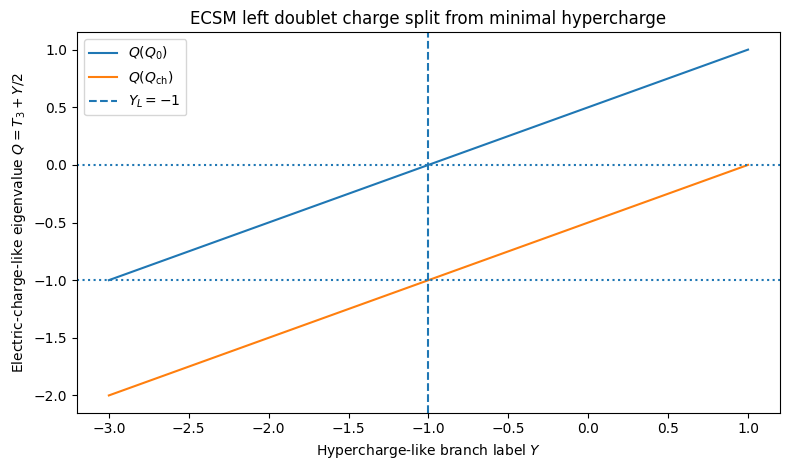

Saved: ecsm_hypercharge_electric_charge_bridge_out/fig1_left_doublet_charge_vs_hypercharge.png


In [5]:
# CELL 5 — Plot charge eigenvalues versus Y

plt.figure(figsize=(8, 4.8))
plt.plot(scan_df["Y"], scan_df["Q_Q0"], label=r"$Q(Q_0)$")
plt.plot(scan_df["Y"], scan_df["Q_Qch"], label=r"$Q(Q_{\rm ch})$")
plt.axvline(-1, linestyle="--", label=r"$Y_L=-1$")
plt.axhline(0, linestyle=":")
plt.axhline(-1, linestyle=":")
plt.xlabel(r"Hypercharge-like branch label $Y$")
plt.ylabel(r"Electric-charge-like eigenvalue $Q=T_3+Y/2$")
plt.title("ECSM left doublet charge split from minimal hypercharge")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig1_left_doublet_charge_vs_hypercharge.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [6]:
# CELL 6 — Right-handed singlet-like branch assignments

singlet_assignments = [
    {
        "state": "Qch_charged_branch_R",
        "T3": 0.0,
        "Y": -2.0,
        "expected_Q": -1.0,
        "ECSM_interpretation": "right-handed charged branch singlet"
    },
    {
        "state": "Q0_neutral_closure_R",
        "T3": 0.0,
        "Y": 0.0,
        "expected_Q": 0.0,
        "ECSM_interpretation": "right-handed neutral closure singlet / sterile candidate"
    }
]

singlet_rows = []
for row in singlet_assignments:
    Qval = row["T3"] + row["Y"]/2
    singlet_rows.append({**row, "Q_ECSM = T3 + Y/2": Qval, "pass": abs(Qval - row["expected_Q"]) < 1e-12})

singlet_df = pd.DataFrame(singlet_rows)
display(singlet_df)

singlet_df.to_csv(OUT / "right_singlet_charge_assignments.csv", index=False)
print("Saved:", OUT / "right_singlet_charge_assignments.csv")

,state,T3,Y,expected_Q,ECSM_interpretation,Q_ECSM = T3 + Y/2,pass
0,Qch_charged_branch_R,0.0,-2.0,-1.0,right-handed charged branch singlet,-1.0,True
1,Q0_neutral_closure_R,0.0,0.0,0.0,right-handed neutral closure singlet / sterile...,0.0,True


Saved: ecsm_hypercharge_electric_charge_bridge_out/right_singlet_charge_assignments.csv


## Interpretation of the right-singlet result

For a right-handed charged branch singlet,

\[
T_i=0,
\qquad
Y_R=-2.
\]

Therefore:

\[
Q(Q_{{\rm ch},R})=0+\frac{-2}{2}=-1.
\]

For a possible right-handed neutral closure singlet,

\[
T_i=0,
\qquad
Y_R=0,
\]

so:

\[
Q(Q_{0,R})=0.
\]

In [7]:
# CELL 7 — Build a compact charge-assignment table

charge_table = pd.DataFrame([
    {"sector": "left doublet", "state": "Q0_L", "T3": +0.5, "Y": -1.0, "Q = T3 + Y/2": 0.0, "interpretation": "neutral closure branch"},
    {"sector": "left doublet", "state": "Qch_L", "T3": -0.5, "Y": -1.0, "Q = T3 + Y/2": -1.0, "interpretation": "charged branch"},
    {"sector": "right singlet", "state": "Qch_R", "T3": 0.0, "Y": -2.0, "Q = T3 + Y/2": -1.0, "interpretation": "charged branch singlet"},
    {"sector": "right singlet", "state": "Q0_R", "T3": 0.0, "Y": 0.0, "Q = T3 + Y/2": 0.0, "interpretation": "neutral closure singlet / sterile candidate"}
])

display(charge_table)

charge_table.to_csv(OUT / "minimal_ecsm_charge_assignment_table.csv", index=False)
print("Saved:", OUT / "minimal_ecsm_charge_assignment_table.csv")

,sector,state,T3,Y,Q = T3 + Y/2,interpretation
0,left doublet,Q0_L,0.5,-1.0,0.0,neutral closure branch
1,left doublet,Qch_L,-0.5,-1.0,-1.0,charged branch
2,right singlet,Qch_R,0.0,-2.0,-1.0,charged branch singlet
3,right singlet,Q0_R,0.0,0.0,0.0,neutral closure singlet / sterile candidate


Saved: ecsm_hypercharge_electric_charge_bridge_out/minimal_ecsm_charge_assignment_table.csv


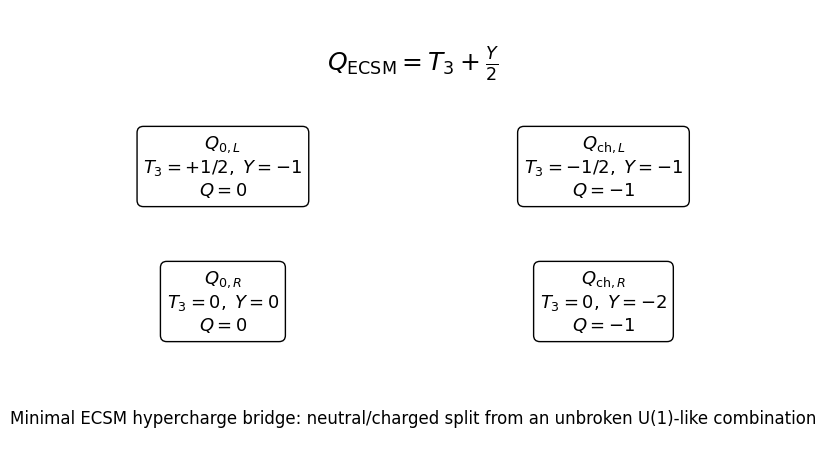

Saved: ecsm_hypercharge_electric_charge_bridge_out/fig2_minimal_charge_assignment_diagram.png


In [8]:
# CELL 8 — Visual diagram of charge construction

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axis("off")

x_left, x_right = 0.25, 0.75
y_top, y_mid = 0.65, 0.35

boxprops = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black")

ax.text(0.5, 0.88, r"$Q_{\rm ECSM}=T_3+\frac{Y}{2}$", ha="center", va="center", fontsize=18)

ax.text(x_left, y_top, r"$Q_{0,L}$" + "\n" + r"$T_3=+1/2,\;Y=-1$" + "\n" + r"$Q=0$",
        ha="center", va="center", fontsize=13, bbox=boxprops)

ax.text(x_right, y_top, r"$Q_{{\rm ch},L}$" + "\n" + r"$T_3=-1/2,\;Y=-1$" + "\n" + r"$Q=-1$",
        ha="center", va="center", fontsize=13, bbox=boxprops)

ax.text(x_left, y_mid, r"$Q_{0,R}$" + "\n" + r"$T_3=0,\;Y=0$" + "\n" + r"$Q=0$",
        ha="center", va="center", fontsize=13, bbox=boxprops)

ax.text(x_right, y_mid, r"$Q_{{\rm ch},R}$" + "\n" + r"$T_3=0,\;Y=-2$" + "\n" + r"$Q=-1$",
        ha="center", va="center", fontsize=13, bbox=boxprops)

ax.text(0.5, 0.08,
        "Minimal ECSM hypercharge bridge: neutral/charged split from an unbroken U(1)-like combination",
        ha="center", fontsize=12)

plt.tight_layout()
fig_path = OUT / "fig2_minimal_charge_assignment_diagram.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [9]:
# CELL 9 — Coherent-limit deformation of charge operator

Delta_T3 = np.array([[0.20, 0.0],
                     [0.0, -0.10]], dtype=complex)

def T3_chi(chi):
    return chi*T3 + (1-chi)*Delta_T3

def Qop_chi(chi, Y=-1.0):
    return T3_chi(chi) + 0.5 * Y * I2

chi_values = np.linspace(0, 1, 101)
chi_rows = []
for chi in chi_values:
    Qop = Qop_chi(chi, Y=-1.0)
    q0_val = eig_charge(Q0, Qop)
    qch_val = eig_charge(Qch, Qop)
    err = float(np.linalg.norm(np.array([q0_val, qch_val]) - np.array([0.0, -1.0])))
    chi_rows.append({"chi": chi, "Q_Q0": q0_val, "Q_Qch": qch_val, "target_error": err})

chi_df = pd.DataFrame(chi_rows)
display(chi_df.head())
display(chi_df.tail())

chi_df.to_csv(OUT / "chi_deformed_charge_recovery.csv", index=False)
print("Saved:", OUT / "chi_deformed_charge_recovery.csv")

,chi,Q_Q0,Q_Qch,target_error
0,0.00,-0.300,-0.600,0.500
1,0.01,-0.297,-0.604,0.495
2,0.02,-0.294,-0.608,0.490
3,0.03,-0.291,-0.612,0.485
4,0.04,-0.288,-0.616,0.480


,chi,Q_Q0,Q_Qch,target_error
96,0.96,-0.012,-0.984,0.020
97,0.97,-0.009,-0.988,0.015
98,0.98,-0.006,-0.992,0.010
99,0.99,-0.003,-0.996,0.005
100,1.00,0.000,-1.000,0.000


Saved: ecsm_hypercharge_electric_charge_bridge_out/chi_deformed_charge_recovery.csv


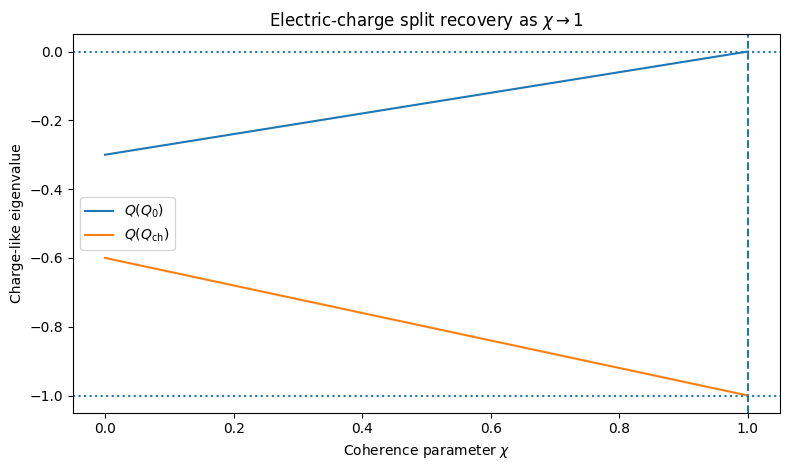

Saved: ecsm_hypercharge_electric_charge_bridge_out/fig3_chi_charge_recovery.png


In [10]:
# CELL 10 — Plot charge recovery under chi deformation

plt.figure(figsize=(8, 4.8))
plt.plot(chi_df["chi"], chi_df["Q_Q0"], label=r"$Q(Q_0)$")
plt.plot(chi_df["chi"], chi_df["Q_Qch"], label=r"$Q(Q_{\rm ch})$")
plt.axhline(0, linestyle=":")
plt.axhline(-1, linestyle=":")
plt.axvline(1, linestyle="--")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel(r"Charge-like eigenvalue")
plt.title(r"Electric-charge split recovery as $\chi \rightarrow 1$")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig3_chi_charge_recovery.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

## Interpretation of \(\chi\)-deformed charge recovery

The exact charge split is recovered when the coherent \(T_3\) structure is recovered:

\[
\chi\rightarrow1
\quad\Rightarrow\quad
T_3(\chi)\rightarrow T_3.
\]

This gives:

\[
Q(Q_0)\rightarrow0,
\qquad
Q(Q_{\rm ch})\rightarrow-1.
\]

ECSM interpretation:

\[
U(1)_{\rm EM}
\]

appears as the surviving coherent charge-like combination of closure imbalance \(T_3\) and branch-phase/hypercharge label \(Y\).

In [11]:
# CELL 11 — Final summary and verdict

left_pass = (
    abs(float(left_charge_df.loc[0, "Q_ECSM = T3 + Y/2"]) - 0.0) < 1e-12
    and abs(float(left_charge_df.loc[1, "Q_ECSM = T3 + Y/2"]) + 1.0) < 1e-12
)

singlet_pass = bool(singlet_df["pass"].all())
best_Y_pass = abs(best["Y"] + 1.0) < 1e-12 and abs(best["target_error"]) < 1e-12

final_label = (
    "PASS_MINIMAL_HYPERCHARGE_ELECTRIC_CHARGE_BRIDGE"
    if left_pass and singlet_pass and best_Y_pass
    else "FAIL_MINIMAL_HYPERCHARGE_ELECTRIC_CHARGE_BRIDGE"
)

summary = {
    "run_label": "ECSM_minimal_hypercharge_electric_charge_bridge",
    "left_doublet": {
        "basis": ["Q0_L", "Qch_L"],
        "Y_L": -1.0,
        "Q_Q0_L": float(left_charge_df.loc[0, "Q_ECSM = T3 + Y/2"]),
        "Q_Qch_L": float(left_charge_df.loc[1, "Q_ECSM = T3 + Y/2"]),
        "pass": left_pass
    },
    "right_singlets": {
        "Qch_R": {"T3": 0.0, "Y": -2.0, "Q": -1.0},
        "Q0_R": {"T3": 0.0, "Y": 0.0, "Q": 0.0},
        "pass": singlet_pass
    },
    "hypercharge_scan": {
        "best_Y": float(best["Y"]),
        "best_target_error": float(best["target_error"]),
        "pass": best_Y_pass
    },
    "interpretation": "Electric charge is recovered as Q_ECSM = T3 + Y/2 for a closure-active ECSM weak pair.",
    "final_label": final_label
}

summary

{'run_label': 'ECSM_minimal_hypercharge_electric_charge_bridge',
 'left_doublet': {'basis': ['Q0_L', 'Qch_L'],
  'Y_L': -1.0,
  'Q_Q0_L': 0.0,
  'Q_Qch_L': -1.0,
  'pass': True},
 'right_singlets': {'Qch_R': {'T3': 0.0, 'Y': -2.0, 'Q': -1.0},
  'Q0_R': {'T3': 0.0, 'Y': 0.0, 'Q': 0.0},
  'pass': True},
 'hypercharge_scan': {'best_Y': -1.0, 'best_target_error': 0.0, 'pass': True},
 'interpretation': 'Electric charge is recovered as Q_ECSM = T3 + Y/2 for a closure-active ECSM weak pair.',
 'final_label': 'PASS_MINIMAL_HYPERCHARGE_ELECTRIC_CHARGE_BRIDGE'}

In [12]:
# CELL 12 — Save output files

with open(OUT / "final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_hypercharge_electric_charge_bridge_out/chi_deformed_charge_recovery.csv
 - ecsm_hypercharge_electric_charge_bridge_out/fig1_left_doublet_charge_vs_hypercharge.png
 - ecsm_hypercharge_electric_charge_bridge_out/fig2_minimal_charge_assignment_diagram.png
 - ecsm_hypercharge_electric_charge_bridge_out/fig3_chi_charge_recovery.png
 - ecsm_hypercharge_electric_charge_bridge_out/final_summary.json
 - ecsm_hypercharge_electric_charge_bridge_out/hypercharge_scan_left_doublet.csv
 - ecsm_hypercharge_electric_charge_bridge_out/left_doublet_charge_assignments.csv
 - ecsm_hypercharge_electric_charge_bridge_out/minimal_ecsm_charge_assignment_table.csv
 - ecsm_hypercharge_electric_charge_bridge_out/right_singlet_charge_assignments.csv


# Paper-grade interpretation

The notebook supports the following narrow statement:

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L
\]

can be supplemented by a minimal \(U(1)\)-like branch-phase / hypercharge label \(Y\) such that

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2}
\]

reproduces the neutral/charged split:

\[
Q(Q_0)=0,
\qquad
Q(Q_{\rm ch})=-1.
\]

The left-active doublet uses:

\[
Y_L=-1,
\]

while the charged right-singlet uses:

\[
Y_R=-2.
\]

A neutral right-singlet / sterile-like closure candidate can be assigned:

\[
Y_R=0.
\]

This does not derive the full electroweak theory, Weinberg mixing, \(W/Z\) masses, or hypercharge quantisation. It establishes a minimal ECSM algebraic bridge from closure-active \(SU(2)_L\) to an emergent electric-charge-like \(U(1)\) combination.